In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# for prettier plot

sns.set_theme(style="whitegrid")

In [22]:
file_path = "/Users/mac/Desktop/apk/csv/feature_vectors_syscallsbinders_frequency_5_Cat.csv"

# loading dataset 
df = pd.read_csv(file_path)

# previewing the first rows
df.head()

,ACCESS_PERSONAL_INFO___,ALTER_PHONE_STATE___,ANTI_DEBUG_____,CREATE_FOLDER_____,CREATE_PROCESS`_____,CREATE_THREAD_____,DEVICE_ACCESS_____,EXECUTE_____,FS_ACCESS____,FS_ACCESS()____,...,utimes,vfork,vibrate,vibratePattern,wait4,watchRotation,windowGainedFocus,write,writev,Class
0,1,0,0,3,0,14,2,0,3,0,...,0,0,0,0,0,0,0,37,10,1
1,3,0,0,6,0,42,91,0,32,0,...,0,0,0,0,0,0,2,2838,46,1
2,2,0,0,4,0,23,3,0,17,2,...,0,0,0,0,0,0,1,111,20,1
3,1,0,0,4,0,27,9,0,36,0,...,0,0,0,0,0,0,7,987,197,1
4,3,0,0,11,0,18,3,0,16,0,...,0,0,0,0,0,0,1,98,25,1


In [5]:
print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nClass distribution:")
print(df['Class'].value_counts())

Shape of dataset: (11598, 471)

Column names:
['ACCESS_PERSONAL_INFO___', 'ALTER_PHONE_STATE___', 'ANTI_DEBUG_____', 'CREATE_FOLDER_____', 'CREATE_PROCESS`_____', 'CREATE_THREAD_____', 'DEVICE_ACCESS_____', 'EXECUTE_____', 'FS_ACCESS____', 'FS_ACCESS()____', 'FS_ACCESS(CREATE)____', 'FS_ACCESS(CREATE__APPEND)__', 'FS_ACCESS(CREATE__READ)__', 'FS_ACCESS(CREATE__READ__WRITE)', 'FS_ACCESS(CREATE__WRITE)__', 'FS_ACCESS(CREATE__WRITE__APPEND)', 'FS_ACCESS(READ)____', 'FS_ACCESS(READ__WRITE)__', 'FS_ACCESS(WRITE)____', 'FS_PIPE_ACCESS___', 'FS_PIPE_ACCESS()___', 'FS_PIPE_ACCESS(READ)___', 'FS_PIPE_ACCESS(READ__)_', 'FS_PIPE_ACCESS(READ__WRITE)_', 'FS_PIPE_ACCESS(WRITE)___', 'NETWORK_ACCESS____', 'NETWORK_ACCESS()____', 'NETWORK_ACCESS(READ)____', 'NETWORK_ACCESS(READ__WRITE)__', 'NETWORK_ACCESS(READ__WRITE__)', 'NETWORK_ACCESS(WRITE)____', 'NETWORK_ACCESS(WRITE__)__', 'SMS_SEND____', 'TERMINATE_PROCESS', 'TERMINATE_THREAD', '__arm_nr_cacheflush', '__arm_nr_set_tls', '_llseek', '_newselect', 

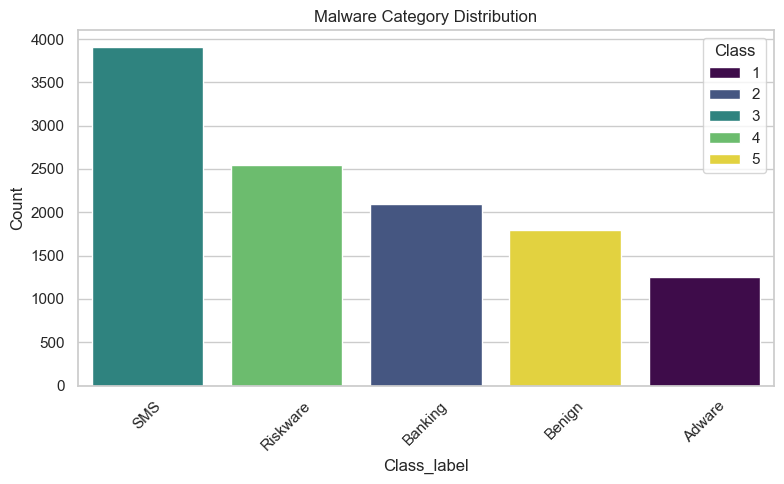

In [6]:
# lable map
label_map = {
    1: "Adware",
    2: "Banking",
    3: "SMS",
    4: "Riskware",
    5: "Benign"
}
# mapping the numeric values in the 'Class' column to the labels
df['Class_label'] = df['Class'].map(label_map)

plt.figure(figsize=(8, 5))
sns.countplot(x='Class_label', data=df, order=df['Class_label'].value_counts().index, palette="viridis", hue="Class")
plt.title("Malware Category Distribution")
plt.xlabel("Class_label")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [11]:
df.head()

,ACCESS_PERSONAL_INFO___,ALTER_PHONE_STATE___,ANTI_DEBUG_____,CREATE_FOLDER_____,CREATE_PROCESS`_____,CREATE_THREAD_____,DEVICE_ACCESS_____,EXECUTE_____,FS_ACCESS____,FS_ACCESS()____,...,vfork,vibrate,vibratePattern,wait4,watchRotation,windowGainedFocus,write,writev,Class,Class_label
0,1,0,0,3,0,14,2,0,3,0,...,0,0,0,0,0,0,37,10,1,Adware
1,3,0,0,6,0,42,91,0,32,0,...,0,0,0,0,0,2,2838,46,1,Adware
2,2,0,0,4,0,23,3,0,17,2,...,0,0,0,0,0,1,111,20,1,Adware
3,1,0,0,4,0,27,9,0,36,0,...,0,0,0,0,0,7,987,197,1,Adware
4,3,0,0,11,0,18,3,0,16,0,...,0,0,0,0,0,1,98,25,1,Adware


In [25]:
X = df.drop(columns=['Class'])  # All system/binder features
y = df['Class']                 # Target labels (1–5)

X.head()

,ACCESS_PERSONAL_INFO___,ALTER_PHONE_STATE___,ANTI_DEBUG_____,CREATE_FOLDER_____,CREATE_PROCESS`_____,CREATE_THREAD_____,DEVICE_ACCESS_____,EXECUTE_____,FS_ACCESS____,FS_ACCESS()____,...,updateServiceLocation,utimes,vfork,vibrate,vibratePattern,wait4,watchRotation,windowGainedFocus,write,writev
0,1,0,0,3,0,14,2,0,3,0,...,0,0,0,0,0,0,0,0,37,10
1,3,0,0,6,0,42,91,0,32,0,...,0,0,0,0,0,0,0,2,2838,46
2,2,0,0,4,0,23,3,0,17,2,...,0,0,0,0,0,0,0,1,111,20
3,1,0,0,4,0,27,9,0,36,0,...,0,0,0,0,0,0,0,7,987,197
4,3,0,0,11,0,18,3,0,16,0,...,0,0,0,0,0,0,0,1,98,25


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)



In [31]:
label_map = {
    1: "Adware", 2: "Banking", 3: "SMS",
    4: "Riskware", 5: "Benign"
}

print(y_train.value_counts().sort_index().rename(index=label_map))

X_train.head()

Class
Adware      1002
Banking     1680
SMS         3123
Riskware    2037
Benign      1436
Name: count, dtype: int64


,ACCESS_PERSONAL_INFO___,ALTER_PHONE_STATE___,ANTI_DEBUG_____,CREATE_FOLDER_____,CREATE_PROCESS`_____,CREATE_THREAD_____,DEVICE_ACCESS_____,EXECUTE_____,FS_ACCESS____,FS_ACCESS()____,...,updateServiceLocation,utimes,vfork,vibrate,vibratePattern,wait4,watchRotation,windowGainedFocus,write,writev
6227,3549,0,0,2,0,10,2,0,16,0,...,0,0,0,0,0,0,0,5,475,45
3009,1,0,0,0,0,8,2,0,4,0,...,0,0,0,0,0,0,0,0,28,5
994,1,0,0,0,0,18,2,0,16,0,...,0,0,0,0,0,0,0,3,204,14
2778,12,0,0,3,1,14,26,1,26,1,...,0,0,0,0,0,1,0,0,955,33
8345,0,0,0,0,0,8,37,0,45,0,...,0,0,0,0,0,0,0,0,95,4


In [32]:
# feature scalling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit the scaler on the training data and transform both train and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# checking the distribution
import numpy as np
# should be closer to 0
print("Mean (train):", np.mean(X_train_scaled))
# should be close to 1
print("Std (train):", np.std(X_train_scaled))

Mean (train): 4.8459501455067306e-18
Std (train): 0.9893045053244831


In [34]:
from sklearn.ensemble import RandomForestClassifier

# Intializing the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# fiting and training the model
rf_model.fit(X_train_scaled,y_train)


RandomForestClassifier(random_state=42)

In [35]:
# predicting the test data

y_pred = rf_model.predict(X_test_scaled)

In [36]:
# Evaluating the model

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# label map
label_map = {
    1: "Adware", 2: "Banking", 3: "SMS",
    4: "Riskware", 5: "Benign"
}

# classification report 
target_names = [label_map[i] for i in sorted(label_map)]

print("Classification Report:")
print(classification_report(y_test,y_pred, target_names=target_names))

Classification Report:
              precision    recall  f1-score   support

      Adware       0.86      0.93      0.89       251
     Banking       0.97      0.90      0.93       420
         SMS       0.98      0.99      0.98       781
    Riskware       0.96      0.92      0.94       509
      Benign       0.91      0.95      0.93       359

    accuracy                           0.95      2320
   macro avg       0.93      0.94      0.94      2320
weighted avg       0.95      0.95      0.95      2320



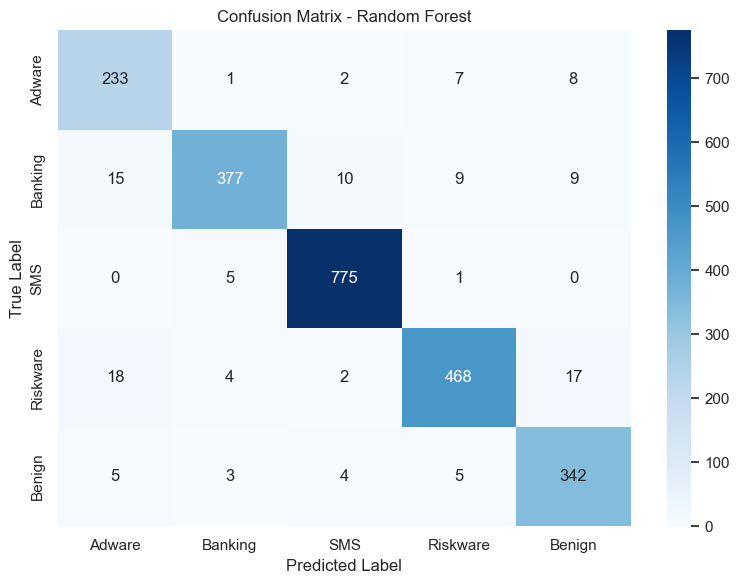


The confusion matrix visualizes the performance of the Random Forest model on the test dataset.
- Rows represent the true labels (actual classes).
- Columns represent the predicted labels (model's predictions).
- Each cell (i, j) shows the number of instances where the true label was i and the predicted label was j.

Diagonal values (top-left to bottom-right) indicate correct predictions, while off-diagonal values represent misclassifications.
For example:
- The top-left cell shows the number of correctly classified 'Adware' samples.
- The bottom-right cell shows the number of correctly classified 'Benign' samples.
- Off-diagonal cells, such as (1, 2), indicate 'Adware' samples misclassified as 'Banking'.

This graph helps identify which classes the model performs well on and where it struggles.



In [38]:
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# Explanation
print("""
The confusion matrix visualizes the performance of the Random Forest model on the test dataset.
- Rows represent the true labels (actual classes).
- Columns represent the predicted labels (model's predictions).
- Each cell (i, j) shows the number of instances where the true label was i and the predicted label was j.

Diagonal values (top-left to bottom-right) indicate correct predictions, while off-diagonal values represent misclassifications.
For example:
- The top-left cell shows the number of correctly classified 'Adware' samples.
- The bottom-right cell shows the number of correctly classified 'Benign' samples.
- Off-diagonal cells, such as (1, 2), indicate 'Adware' samples misclassified as 'Banking'.

This graph helps identify which classes the model performs well on and where it struggles.
""")

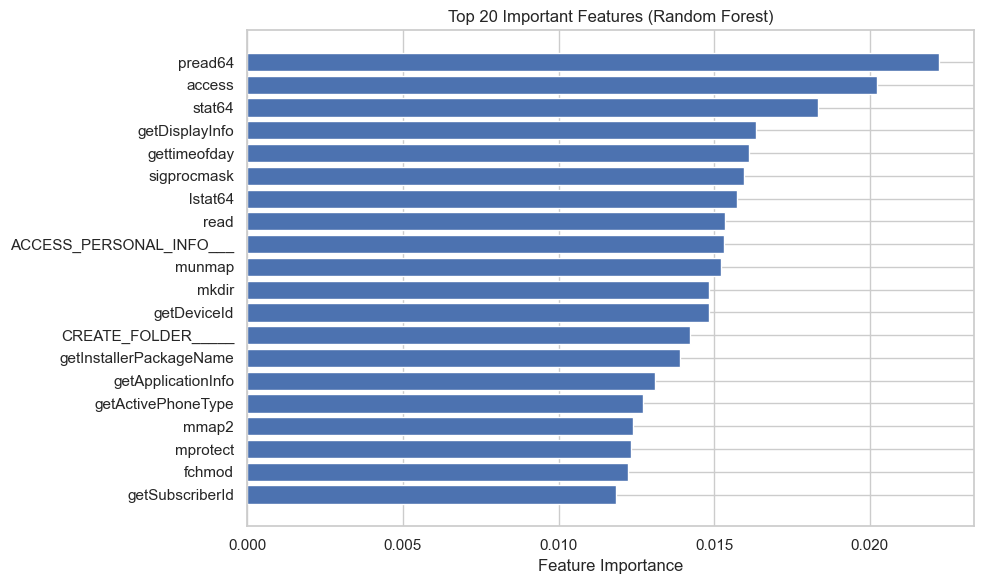

In [42]:
import numpy as np

# Get feature importances
importances = rf_model.feature_importances_
feature_names = X.columns

# Sort top N important features
N = 20
indices = np.argsort(importances)[-N:]

plt.figure(figsize=(10, 6))
plt.barh(range(N), importances[indices], align='center')
plt.yticks(range(N), [feature_names[i] for i in indices])
plt.xlabel("Feature Importance")
plt.title(f"Top {N} Important Features (Random Forest)")
plt.tight_layout()
plt.show()



In [43]:
# exporting the model

import joblib

# Save the model to a file
joblib.dump(rf_model, 'apk_forest_model.pkl')

# saving the scaler
joblib.dump(scaler, 'apk_forest_scaler.pkl')

print("Model and scaler saved successfully.")

Model and scaler saved successfully.


In [49]:
# Deep Learning Model with TensorFlow

import tensorflow as tf
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical


# convert int to one-hot encoding format
num_classes = 5
y_train_oh = to_categorical(y_train -1, num_classes=num_classes)
y_test_oh = to_categorical(y_test-1, num_classes=num_classes)


In [50]:
# sequential is a model that allows you to build a model layer by layer


model = Sequential([

    Input(shape=(X_train_scaled.shape[1],)),
    # First hidden layer with 256 neurons and ReLU activation
    Dense(256, activation='relu'),
    Dropout(0.3),  # Dropout helps reduce overfitting

    # Second hidden layer
    Dense(128, activation='relu'),
    Dropout(0.3),

    # Third hidden layer
    Dense(64, activation='relu'),

    # Output layer with softmax (multi-class classification)
    Dense(num_classes, activation='softmax')
])


In [51]:
# compiling model learning process

model.compile(
    optimizer='adam', #Adam optimizer is an adaptive laerning rate optimization algorithm
    loss = 'categorical_crossentropy', #Loss function for multi-class classification
    metrics=['accuracy'] #Metric to evaluate the model
)

In [52]:
# training the model

history = model.fit(
    X_train_scaled, y_train_oh,
    validation_split=0.2,  # 20% of training data will be used for validation
    epochs=20,             # Number of passes through the full dataset
    batch_size=32,         # Number of samples per weight update
    verbose=2              # Show training progress
)
# why history is used is to store the training history of the model, including loss and accuracy metrics for each epoch.

Epoch 1/20
232/232 - 2s - 9ms/step - accuracy: 0.6815 - loss: 0.9257 - val_accuracy: 0.7710 - val_loss: 0.7019
Epoch 2/20
232/232 - 1s - 2ms/step - accuracy: 0.8072 - loss: 0.6139 - val_accuracy: 0.8238 - val_loss: 0.6282
Epoch 3/20
232/232 - 1s - 2ms/step - accuracy: 0.8409 - loss: 0.4998 - val_accuracy: 0.8367 - val_loss: 0.5759
Epoch 4/20
232/232 - 1s - 2ms/step - accuracy: 0.8587 - loss: 0.4491 - val_accuracy: 0.8400 - val_loss: 0.6009
Epoch 5/20
232/232 - 1s - 2ms/step - accuracy: 0.8715 - loss: 0.4030 - val_accuracy: 0.8567 - val_loss: 0.5671
Epoch 6/20
232/232 - 1s - 2ms/step - accuracy: 0.8760 - loss: 0.3900 - val_accuracy: 0.8583 - val_loss: 0.5558
Epoch 7/20
232/232 - 1s - 2ms/step - accuracy: 0.8859 - loss: 0.3548 - val_accuracy: 0.8594 - val_loss: 0.5676
Epoch 8/20
232/232 - 1s - 2ms/step - accuracy: 0.8945 - loss: 0.3367 - val_accuracy: 0.8642 - val_loss: 0.5422
Epoch 9/20
232/232 - 1s - 2ms/step - accuracy: 0.8973 - loss: 0.3202 - val_accuracy: 0.8696 - val_loss: 0.5658
E

In [53]:
# Evaluate on test data
test_loss, test_acc = model.evaluate(X_test_scaled, y_test_oh, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}")



Test Accuracy: 0.9047


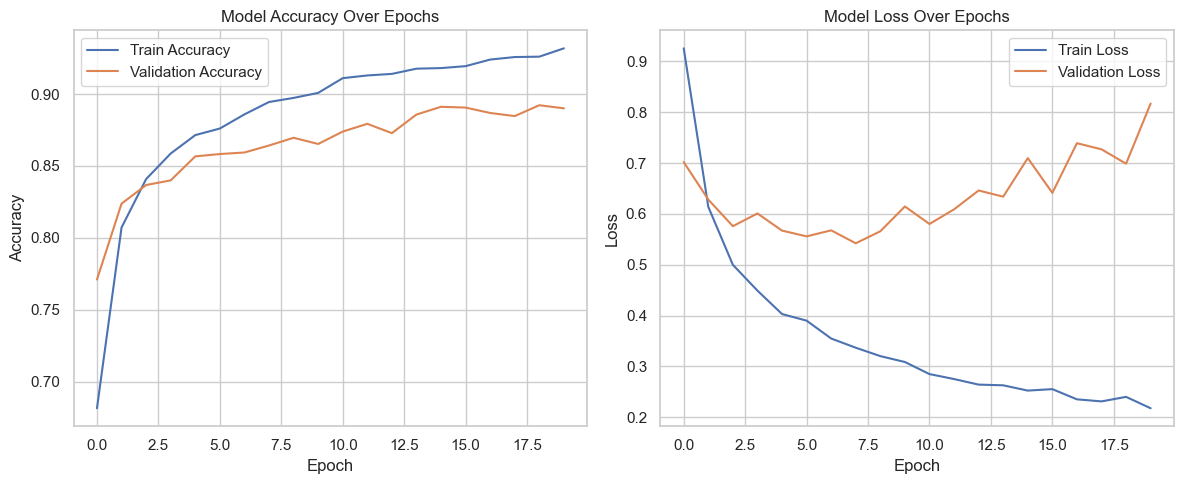

In [54]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
The graph in **Cell Index: 22** visualizes the training and validation performance of the deep learning model over the epochs. It consists of two subplots:
